# Pokémon analytics

In [1]:
import pandas as pd
import os

In [2]:
files = [file for file in os.listdir("./pokemon_data")]

pokemon_gen_data = pd.DataFrame()

for file in files:
    df = pd.read_csv("./pokemon_data/"+file)
    pokemon_gen_data = pd.concat([pokemon_gen_data, df])
    
pokemon_gen_data.to_csv("pokemon_two_gen_data.csv", index=False)

### Please refer here:
https://stackoverflow.com/questions/3207219/how-do-i-list-all-files-of-a-directory

This will allow us to read all files in the directory.

### Please also refer here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html

This will allow us to join the datasheets that we've just read.

In [3]:
pokedata = pd.read_csv("pokemon_two_gen_data.csv")
pokedata

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
4,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,Pupitar,Rock,Ground,410,70,84,70,65,70,51,2,False
247,248,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,2,False
248,249,Lugia,Psychic,Flying,680,106,90,130,90,154,110,2,True
249,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True


We need to add some content to the dataframe before we answer questions. First, let's list out the columns that we have.

In [4]:
pokedata.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

We need to add the column 'MAIN TYPE' so we can later sort on that:

In [5]:
pokedata['Main Type'] = pokedata['Type 1']
pokedata[['Name','Main Type','Type 1','Type 2']]

,Name,Main Type,Type 1,Type 2
0,Bulbasaur,Grass,Grass,Poison
1,Ivysaur,Grass,Grass,Poison
2,Venusaur,Grass,Grass,Poison
3,Charmander,Fire,Fire,NaN
4,Charmeleon,Fire,Fire,NaN
...,...,...,...,...
246,Pupitar,Rock,Rock,Ground
247,Tyranitar,Rock,Rock,Dark
248,Lugia,Psychic,Psychic,Flying
249,Ho-oh,Fire,Fire,Flying


Let's ensure that we have our two generations correctly merged together:

In [6]:
pokedata.iloc[0:151]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Main Type
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,Grass
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,Grass
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,Grass
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,Fire
4,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,147,Dratini,Dragon,NaN,300,41,64,45,50,50,50,1,False,Dragon
147,148,Dragonair,Dragon,NaN,420,61,84,65,70,70,70,1,False,Dragon
148,149,Dragonite,Dragon,Flying,600,91,134,95,100,100,80,1,False,Dragon
149,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True,Psychic


In [8]:
pokedata.iloc[151:251]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Main Type
151,152,Chikorita,Grass,NaN,318,45,49,65,49,65,45,2,False,Grass
152,153,Bayleef,Grass,NaN,405,60,62,80,63,80,60,2,False,Grass
153,154,Meganium,Grass,NaN,525,80,82,100,83,100,80,2,False,Grass
154,155,Cyndaquil,Fire,NaN,309,39,52,43,60,50,65,2,False,Fire
155,156,Quilava,Fire,NaN,405,58,64,58,80,65,80,2,False,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,Pupitar,Rock,Ground,410,70,84,70,65,70,51,2,False,Rock
247,248,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,2,False,Rock
248,249,Lugia,Psychic,Flying,680,106,90,130,90,154,110,2,True,Psychic
249,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True,Fire


Further drill down is allowed:

In [9]:
pokedata.iloc[149,1:11]

Name        Mewtwo
Type 1     Psychic
Type 2         NaN
Total          680
HP             106
Attack         110
Defense         90
Sp. Atk        154
Sp. Def         90
Speed          130
Name: 149, dtype: object

Besides adding a 'MAIN TYPE', we also need to add a 'TOTAL' category:

In [10]:
pokedata['Total'] = pokedata['HP'] + pokedata['Attack'] + pokedata['Defense'] + pokedata['Sp. Atk'] + pokedata['Sp. Def'] + pokedata['Speed']
pokedata

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Main Type
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,Grass
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,Grass
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,Grass
3,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,Fire
4,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,Pupitar,Rock,Ground,410,70,84,70,65,70,51,2,False,Rock
247,248,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,2,False,Rock
248,249,Lugia,Psychic,Flying,680,106,90,130,90,154,110,2,True,Psychic
249,250,Ho-oh,Fire,Flying,680,106,130,90,110,154,90,2,True,Fire


We can even rearrange the columns so we can line up 'MAIN TYPE' next to 'TYPE 1':

In [11]:
cols = list(pokedata.columns.values)
rearrange_pokedata = pokedata[cols[0:2] + [cols[-1]] + cols[2:13]]
rearrange_pokedata

,#,Name,Main Type,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Grass,Poison,525,80,82,83,100,100,80,1,False
3,4,Charmander,Fire,Fire,NaN,309,39,52,43,60,50,65,1,False
4,5,Charmeleon,Fire,Fire,NaN,405,58,64,58,80,65,80,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,Pupitar,Rock,Rock,Ground,410,70,84,70,65,70,51,2,False
247,248,Tyranitar,Rock,Rock,Dark,600,100,134,110,95,100,61,2,False
248,249,Lugia,Psychic,Psychic,Flying,680,106,90,130,90,154,110,2,True
249,250,Ho-oh,Fire,Fire,Flying,680,106,130,90,110,154,90,2,True


## Let's start answering some questions:

### How many different Pokémon were introduced per generation?

In [12]:
generation = pokedata.groupby('Generation').count()

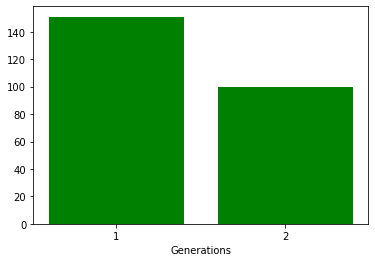

In [13]:
import matplotlib.pyplot as plt

gens = range(1,3)

plt.bar(gens, generation['#'], color='green')
plt.xticks(gens)
plt.xlabel('Generations')

plt.show()

Generation I introduced 151 and Generation II introduced another 100.

### How many legendaries are in each generation?

In [14]:
legendary = pokedata.groupby('Generation').sum()

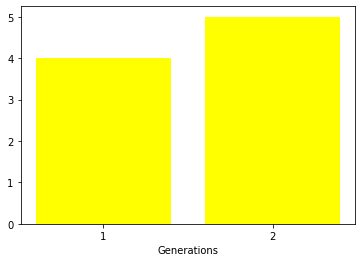

In [15]:
import matplotlib.pyplot as plt

gens = range(1,3)

plt.bar(gens, legendary['Legendary'], color='yellow')
plt.xticks(gens)
plt.xlabel('Generations')

plt.show()

Generation I introduced 4: Articuno, Zapdos, Moltres, and Mewtwo.
<br>
Generation II introduced 5: Suicune, Raikou, Entei, Lugia, and Ho-oh.

### Which types have the largest and smallest families?

In [16]:
pokedata_count = pokedata.groupby('Main Type').count()
pokedata_count.sort_values('#', ascending=False)['#']

Main Type
Water       46
Normal      44
Bug         22
Grass       21
Fire        20
Electric    15
Poison      15
Psychic     15
Rock        13
Ground      11
Fighting     9
Ice          6
Dark         5
Ghost        4
Dragon       3
Steel        2
Name: #, dtype: int64

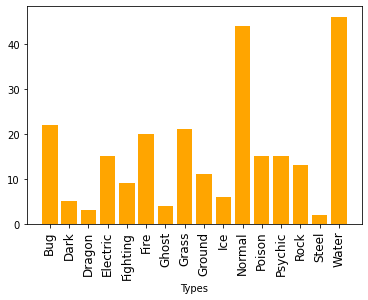

In [17]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, pokedata_count['#'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

The last few types: Dark, Ghost, Dragon, and Steel aren't surprising.
    
Dark and Steel are new entries in Generation II, and while Dragon got an addition, it's Kingdra whose secondary type is Dragon. Including that, this brings that family to just 4. Ghost type only got an extra addition overall in Misdreavus.

### Which types have the strongest and weakest stats overall?

This is a quick statistical description:

In [18]:
pokedata.describe()[['Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000
mean,406.721116,66.749004,70.840637,68.729084,66.007968,68.458167,65.936255
std,104.702712,29.797261,27.361844,30.399841,27.323688,27.452236,27.143101
min,180.000000,10.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,320.000000,49.000000,50.000000,49.500000,45.000000,50.000000,45.000000
50%,410.000000,65.000000,70.000000,65.000000,65.000000,65.000000,65.000000
75%,490.000000,80.000000,90.000000,85.000000,85.000000,85.000000,85.000000
max,680.000000,255.000000,134.000000,230.000000,154.000000,230.000000,140.000000


This is breaking it down by types:

In [19]:
total_mean = pokedata.groupby('Main Type').mean()
total_mean.sort_values('Total', ascending=False)['Total']

Main Type
Steel       487.500000
Psychic     473.133333
Fire        450.000000
Dragon      440.000000
Dark        438.000000
Rock        423.461538
Electric    420.000000
Water       413.652174
Ghost       412.500000
Grass       395.523810
Ice         395.000000
Fighting    394.444444
Poison      393.600000
Ground      386.818182
Normal      378.568182
Bug         362.727273
Name: Total, dtype: float64

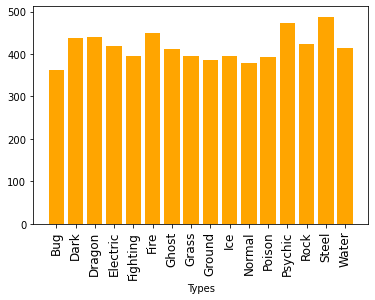

In [20]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Total'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

This might look a bit surprising, but it really isn't due to Steel type's defence being carried heavily by Steelix. The other main Steel type, Skarmony, has a base defensive state of 140, which means the small sample gives Steel an average of 170 points overall.

Bug types have some good stats in Heracross, Scizor, and Pinsir, but they are being weighed down by a plethora of really weak Pokémon whose evolutionary lines aren't really that great either.

### Which Pokémon have the strongest and weakest stats overall?

In [21]:
poke_total_mean = pokedata.groupby('Name').mean()
poke_total_mean.sort_values('Total', ascending=False)[['#','Total']].head(13)

,#,Total
Name,,
Ho-oh,250,680
Mewtwo,150,680
Lugia,249,680
Dragonite,149,600
Celebi,251,600
Mew,151,600
Tyranitar,248,600
Moltres,146,580
Zapdos,145,580


Unsurprisingly, 10 of the top 13 Pokémon with the highest stats are legendaries. Dragonite and Tyranitar are pseudo-legendaries introduced in their respective generations:

https://bulbapedia.bulbagarden.net/wiki/Pseudo-legendary_Pok%C3%A9mon

And then there's Mew, the Pokémon that can learn any move that the legendary Mewtwo is based off of.

In [22]:
poke_total_mean.sort_values('Total', ascending=False)[['#','Total']].tail(10)

,#,Total
Name,,
Igglybuff,174,210
Wooper,194,210
Tyrogue,236,210
Kakuna,14,205
Metapod,11,205
Pichu,172,205
Magikarp,129,200
Caterpie,10,195
Weedle,13,195


On the other side, the Pokémon with the lowest overall stats are either baby Pokémon (Igglybuff, Tyrogue, Pichu) or not fully evolved Pokémon (Kakuna, Metapod). Kakuna and Metapod's previous evolutions, Weedle and Catepie, are both bug types, which as mentioned above are truly weak Pokémon. Wooper and Magikarp are weak now, but their evolutions Quagsire and Gyarados will be much improved. Sunkern on the other hand...

### How do the Pokémon types perform for each generation?

In [23]:
pokedata_1 = pokedata.iloc[0:151]
pokedata_2 = pokedata.iloc[151:251]

In [24]:
gen_1_total_mean = pokedata_1.groupby('Main Type').mean()
gen_1_total_mean.sort_values('Total', ascending=False)['Total']

Main Type
Ice         517.500000
Psychic     470.125000
Fire        455.583333
Electric    444.444444
Dragon      440.000000
Rock        420.555556
Fighting    412.142857
Water       411.214286
Grass       409.416667
Ghost       405.000000
Poison      383.500000
Normal      382.291667
Ground      374.375000
Bug         336.250000
Name: Total, dtype: float64

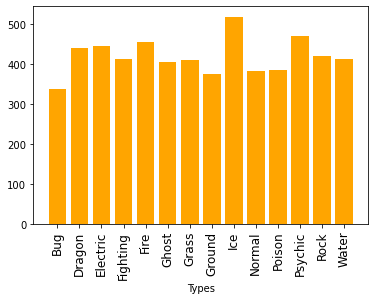

In [25]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Total'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [26]:
gen_2_total_mean = pokedata_2.groupby('Main Type').mean()
gen_2_total_mean.sort_values('Total', ascending=False)['Total']

Main Type
Poison      535.000000
Steel       487.500000
Psychic     476.571429
Fire        441.625000
Dark        438.000000
Ghost       435.000000
Rock        430.000000
Ground      420.000000
Water       417.444444
Bug         394.500000
Electric    383.333333
Grass       377.000000
Normal      374.100000
Ice         333.750000
Fighting    332.500000
Name: Total, dtype: float64

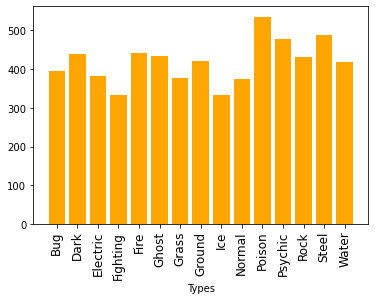

In [27]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Total'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Led by Articuno and Jynx, Ice types lead Generation I and beat out Psychic despite having Mew and Mewtwo on that side.

In Generation II, Poison took the surprising lead by only having Crobat introduced to that generation. With pretty decent stats, Crobat (and Poison) took pole position. Psychic and Fire maintained their high positions and were joined by the new entrant Steel. Both Ice and Fighting new members join their ranks, and their positions plunged to the very bottom join Normal who continue to perform poorly. Water types maintained their middling status.

### Who are the top and bottom Pokémon for each generations?

In [28]:
gen_1_poke_mean = pokedata_1.groupby('Name').mean()
gen_2_poke_mean = pokedata_2.groupby('Name').mean()

In [29]:
gen_1_poke_mean.sort_values('Total', ascending=False)[['#','Total']].head(3)

,#,Total
Name,,
Mewtwo,150,680
Dragonite,149,600
Mew,151,600


In [30]:
gen_1_poke_mean.sort_values('Total', ascending=False)[['#','Total']].tail(3)

,#,Total
Name,,
Magikarp,129,200
Weedle,13,195
Caterpie,10,195


In [31]:
gen_2_poke_mean.sort_values('Total', ascending=False)[['#','Total']].head(4)

,#,Total
Name,,
Ho-oh,250,680
Lugia,249,680
Celebi,251,600
Tyranitar,248,600


In [32]:
gen_2_poke_mean.sort_values('Total', ascending=False)[['#','Total']].tail(5)

,#,Total
Name,,
Igglybuff,174,210
Tyrogue,236,210
Wooper,194,210
Pichu,172,205
Sunkern,191,180


No surprises for each generation as the top performers are led by either legendary or pseudo-legendary Pokémon, and the bottom performers are either babies or really weak Pokémon. Only Magikarp will evolve and escape this fate.

### What about the other stats categories?

Remember we already have total mean, so we would just sort on the proper category:

In [33]:
total_mean.sort_values('HP', ascending=False)['HP']

Main Type
Normal      79.409091
Psychic     75.000000
Steel       70.000000
Water       69.173913
Dark        66.000000
Poison      65.866667
Ice         65.833333
Fire        64.850000
Ground      64.545455
Dragon      64.333333
Grass       62.380952
Rock        59.615385
Fighting    58.888889
Electric    57.333333
Bug         55.909091
Ghost       48.750000
Name: HP, dtype: float64

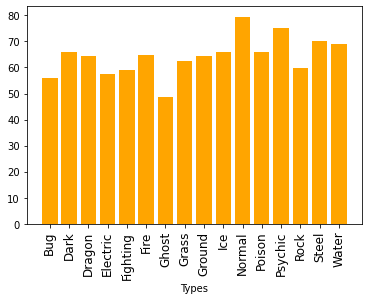

In [34]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['HP'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Normal and Psychic types are being led by Blissey, Snorlax, Lugia, Mewtwo, etc who all have a large amount of hit points. Bug and Ghost rank bottom due to Bug types being incredibly weak and Ghost types having the Ghastly family and Misdreavus who are both below average in the hit points category.

In [35]:
total_mean.sort_values('Attack', ascending=False)['Attack']

Main Type
Fighting    94.444444
Dragon      94.000000
Rock        86.307692
Ground      82.727273
Steel       82.500000
Fire        80.850000
Dark        79.000000
Poison      75.466667
Water       69.413043
Bug         66.136364
Grass       64.809524
Normal      64.477273
Psychic     64.400000
Ice         61.666667
Electric    61.066667
Ghost       52.500000
Name: Attack, dtype: float64

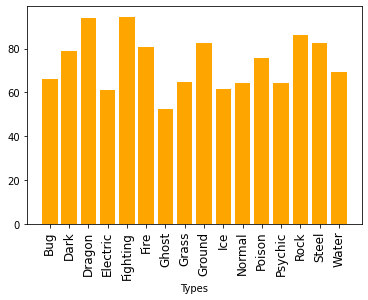

In [36]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Attack'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Led by Pokémon such as Dragonite and Machamp, both the Dragon and Fighting categories top the chart in attack.

In [37]:
total_mean.sort_values('Defense', ascending=False)['Defense']

Main Type
Steel       170.000000
Rock        102.692308
Ground       88.636364
Water        75.543478
Bug          70.681818
Dragon       68.333333
Poison       67.866667
Grass        67.619048
Fire         65.100000
Psychic      64.733333
Fighting     61.888889
Electric     59.266667
Dark         57.400000
Normal       54.818182
Ice          52.500000
Ghost        48.750000
Name: Defense, dtype: float64

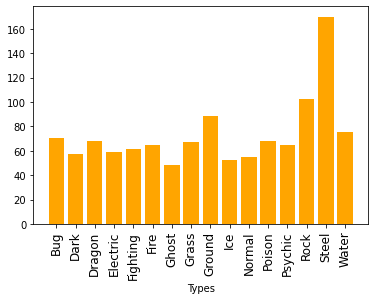

In [39]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Defense'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Steel type skews this statistic with Steelix's base 230 and Skarmory's base 140 defensive stats. Rock types come in at a distant second with members such as Golem and Rhydon.

In [40]:
total_mean.sort_values('Sp. Atk', ascending=False)['Sp. Atk']

Main Type
Ghost       107.500000
Psychic      94.666667
Electric     86.333333
Fire         84.200000
Grass        76.666667
Ice          75.000000
Dark         74.000000
Dragon       73.333333
Water        66.173913
Rock         60.000000
Poison       58.000000
Normal       55.113636
Steel        47.500000
Bug          47.272727
Fighting     42.777778
Ground       40.909091
Name: Sp. Atk, dtype: float64

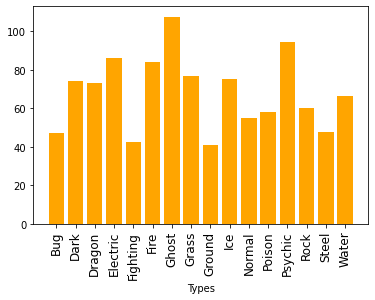

In [41]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Sp. Atk'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Ghost type leads the way in special attack thanks to Gengar whose base 130 special attack stat dragged this group to the top. Psychic comes unsurprisingly second with a plethora of special attackers such as Mewtwo, Alazakam, and Mew.

In [42]:
total_mean.sort_values('Sp. Def', ascending=False)['Sp. Def']

Main Type
Psychic     87.000000
Fire        76.200000
Dark        75.400000
Dragon      73.333333
Fighting    73.333333
Ice         70.000000
Water       69.891304
Electric    69.666667
Grass       68.809524
Bug         68.181818
Steel       67.500000
Normal      63.386364
Poison      62.866667
Ghost       62.500000
Rock        60.384615
Ground      51.818182
Name: Sp. Def, dtype: float64

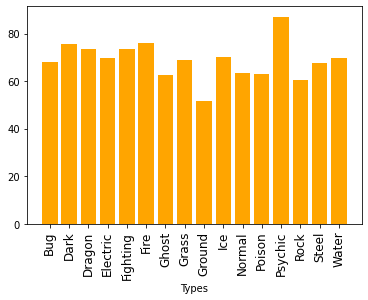

In [43]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Sp. Def'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Besides being second in special attack, Psychics top the chart in special defence. Lugia and Slowking are vaunted Psychic special defenders. Rock and Ground types, who are strong in physics defence, do poorly in special defence.

In [44]:
total_mean.sort_values('Speed', ascending=False)['Speed']

Main Type
Ghost       92.500000
Psychic     87.333333
Electric    86.333333
Dark        86.200000
Fire        78.800000
Ice         70.000000
Dragon      66.666667
Poison      63.533333
Water       63.456522
Fighting    63.111111
Normal      61.363636
Ground      58.181818
Grass       55.238095
Bug         54.545455
Rock        54.461538
Steel       50.000000
Name: Speed, dtype: float64

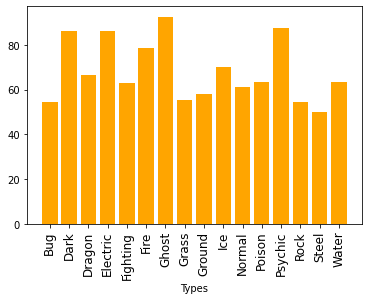

In [45]:
types = [maintype for maintype, pokedata in pokedata_count.groupby(['Main Type'])]

plt.bar(types, total_mean['Speed'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

As the same with special attack, Ghost and Psychic take the no.1 and no.2 spots in speed. Electric and Dark are right behind them thanks to Electrode and Jolteon (for Electric) and Sneasel and Houndoom (for Dark).

### How do each individual stats category perform for each generation?

Since both gen_1_total_mean and gen_2_total_mean have both been defined above, then:

In [46]:
gen_1_total_mean.sort_values('HP', ascending=False)['HP']

Main Type
Normal      79.000000
Ice         77.500000
Grass       65.000000
Water       64.535714
Poison      64.500000
Dragon      64.333333
Psychic     63.875000
Fire        63.833333
Fighting    63.571429
Ground      58.125000
Bug         55.416667
Electric    54.444444
Rock        53.888889
Ghost       45.000000
Name: HP, dtype: float64

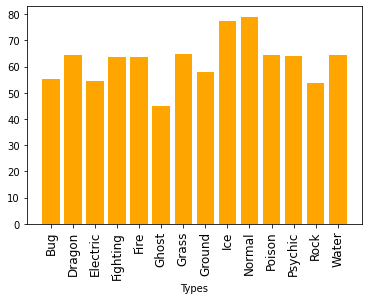

In [47]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['HP'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [48]:
gen_2_total_mean.sort_values('HP', ascending=False)['HP']

Main Type
Psychic     87.714286
Poison      85.000000
Ground      81.666667
Normal      79.900000
Water       76.388889
Rock        72.500000
Steel       70.000000
Fire        66.375000
Dark        66.000000
Electric    61.666667
Ghost       60.000000
Ice         60.000000
Grass       58.888889
Bug         56.500000
Fighting    42.500000
Name: HP, dtype: float64

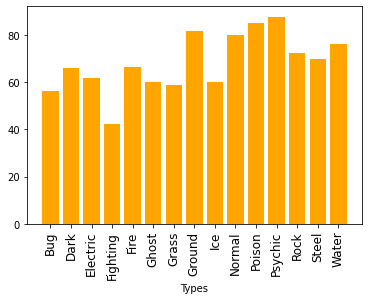

In [49]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['HP'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Chansey and Articuno help push their cateogories to the top in Generation I with their large hit points. Despite introduction of Blissey and Piloswine in Generation II, Ground and Poison edges them out thanks to Donphan and Crobat.

In [50]:
gen_1_total_mean.sort_values('Attack', ascending=False)['Attack']

Main Type
Fighting    102.857143
Dragon       94.000000
Fire         83.916667
Rock         82.222222
Ground       81.875000
Poison       74.428571
Grass        70.666667
Water        70.250000
Ice          67.500000
Normal       66.875000
Bug          63.750000
Electric     62.000000
Psychic      60.125000
Ghost        50.000000
Name: Attack, dtype: float64

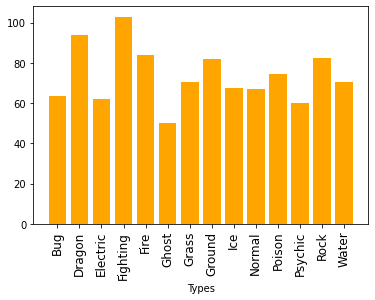

In [51]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Attack'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [52]:
gen_2_total_mean.sort_values('Attack', ascending=False)['Attack']

Main Type
Rock        95.500000
Poison      90.000000
Ground      85.000000
Steel       82.500000
Dark        79.000000
Fire        76.250000
Psychic     69.285714
Bug         69.000000
Water       68.111111
Fighting    65.000000
Normal      61.600000
Ghost       60.000000
Electric    59.666667
Ice         58.750000
Grass       57.000000
Name: Attack, dtype: float64

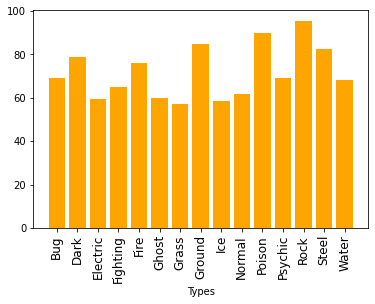

In [53]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Attack'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Dragonite and Machamp led Dragon and Fighting in attack in Generation I, but with only the introduction of Kingdra's dragon type as a secondary type along with the baby Pokémon Tyrogue and his evolution Hitmontop, the pole position was vacated and taken over by Rock and Poison thanks to Tyranitar and Crobat.

In [54]:
gen_1_total_mean.sort_values('Defense', ascending=False)['Defense']

Main Type
Rock        110.000000
Ground       86.250000
Water        77.500000
Grass        69.583333
Dragon       68.333333
Ice          67.500000
Poison       67.000000
Electric     64.666667
Fire         62.583333
Fighting     61.000000
Psychic      57.500000
Bug          57.083333
Normal       54.125000
Ghost        45.000000
Name: Defense, dtype: float64

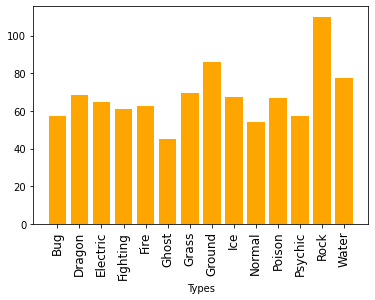

In [55]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Defense'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [56]:
gen_2_total_mean.sort_values('Defense', ascending=False)['Defense']

Main Type
Steel       170.000000
Ground       95.000000
Bug          87.000000
Rock         86.250000
Poison       80.000000
Psychic      73.000000
Water        72.500000
Fire         68.875000
Fighting     65.000000
Grass        65.000000
Ghost        60.000000
Dark         57.400000
Normal       55.650000
Electric     51.166667
Ice          45.000000
Name: Defense, dtype: float64

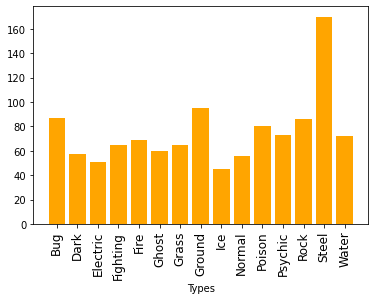

In [57]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Defense'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Rock tops Generation I due to Golem and Rhydon, and Steel tops Generation II due to Skarmory and Steelix. Ice type sinks in defence this generation due to the introduction of the baby Pokémon Smoochum, but it's also due to weak defences from Delibird and Sneasel as well.

In [58]:
gen_1_total_mean.sort_values('Sp. Atk', ascending=False)['Sp. Atk']

Main Type
Ghost       115.000000
Ice         105.000000
Psychic     103.750000
Electric     91.111111
Grass        87.916667
Fire         84.583333
Dragon       73.333333
Water        64.821429
Rock         60.555556
Poison       57.142857
Normal       53.458333
Bug          47.500000
Fighting     45.000000
Ground       39.375000
Name: Sp. Atk, dtype: float64

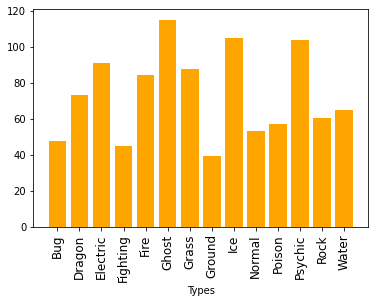

In [59]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Sp. Atk'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [60]:
gen_2_total_mean.sort_values('Sp. Atk', ascending=False)['Sp. Atk']

Main Type
Ghost       85.000000
Psychic     84.285714
Fire        83.625000
Electric    79.166667
Dark        74.000000
Poison      70.000000
Water       68.277778
Grass       61.666667
Ice         60.000000
Rock        58.750000
Normal      57.100000
Steel       47.500000
Bug         47.000000
Ground      45.000000
Fighting    35.000000
Name: Sp. Atk, dtype: float64

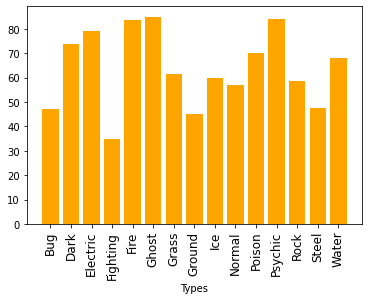

In [61]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Sp. Atk'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Gengar, Jynx, and Mewtwo carry their respective types for Generation I, while ground types are very strong in attack but very weak in special attack. Ghost and Psychic maintain their top two positions in Generation II, but Ice has been dethroned by Fire thanks to Ho-oh and Entei being introduced, and they are both legendary Pokémon.

In [62]:
gen_1_total_mean.sort_values('Sp. Def', ascending=False)['Sp. Def']

Main Type
Ice         110.000000
Psychic      91.875000
Fire         76.666667
Fighting     73.571429
Dragon       73.333333
Electric     73.333333
Water        66.392857
Grass        64.166667
Poison       61.642857
Normal       61.333333
Rock         55.555556
Bug          55.416667
Ghost        55.000000
Ground       50.625000
Name: Sp. Def, dtype: float64

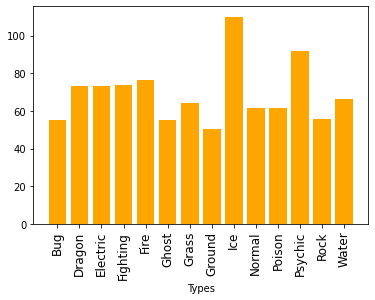

In [63]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Sp. Def'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [64]:
gen_2_total_mean.sort_values('Sp. Def', ascending=False)['Sp. Def']

Main Type
Ghost       85.000000
Bug         83.500000
Psychic     81.428571
Poison      80.000000
Fire        75.500000
Dark        75.400000
Water       75.333333
Grass       75.000000
Fighting    72.500000
Rock        71.250000
Steel       67.500000
Normal      65.850000
Electric    64.166667
Ground      55.000000
Ice         50.000000
Name: Sp. Def, dtype: float64

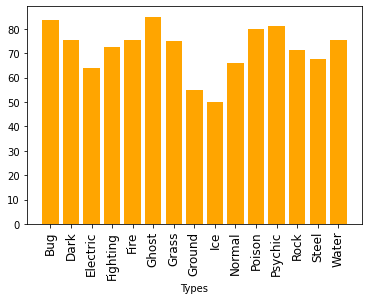

In [65]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Sp. Def'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Thanks to Articuno once again, Ice tops special defence. Like attack and special attack, Ground do great with defence but terribly with special defence. There's a bit of shakeup in Generation as Ledian, Scizor, and Shuckle are all introduced with really good special defences.

In [66]:
gen_1_total_mean.sort_values('Speed', ascending=False)['Speed']

Main Type
Electric    98.888889
Ghost       95.000000
Psychic     93.000000
Ice         90.000000
Fire        84.000000
Water       67.714286
Normal      67.500000
Dragon      66.666667
Fighting    66.142857
Poison      58.785714
Rock        58.333333
Ground      58.125000
Bug         57.083333
Grass       52.083333
Name: Speed, dtype: float64

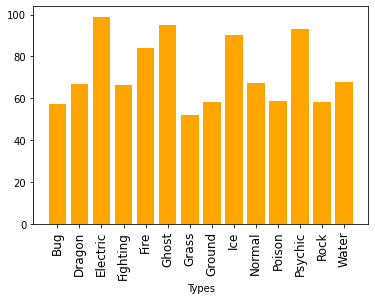

In [67]:
types = [maintype for maintype, pokedata in pokedata_1.groupby(['Main Type'])]

plt.bar(types, gen_1_total_mean['Speed'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

In [68]:
gen_2_total_mean.sort_values('Speed', ascending=False)['Speed']

Main Type
Poison      130.000000
Dark         86.200000
Ghost        85.000000
Psychic      80.857143
Fire         71.000000
Electric     67.500000
Ice          60.000000
Grass        59.444444
Ground       58.333333
Water        56.833333
Normal       54.000000
Fighting     52.500000
Bug          51.500000
Steel        50.000000
Rock         45.750000
Name: Speed, dtype: float64

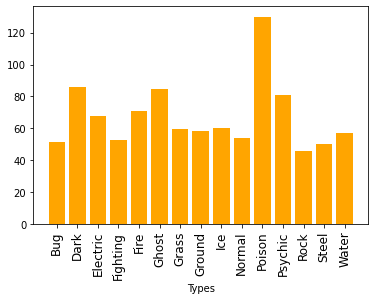

In [69]:
types = [maintype for maintype, pokedata in pokedata_2.groupby(['Main Type'])]

plt.bar(types, gen_2_total_mean['Speed'], color='orange')
plt.xticks(types, rotation='vertical', size=12)
plt.xlabel('Types')

plt.show()

Electric led Generation I with Electrode and Jolteon, but even with the introduction of Raikou, Electric fell to the middle of the pack. Poison takes pole position thanks to Crobat and it's the only category to top over 100 on average (with Crobat being the only member, of course).

### A group within a group: What about the just the legendaries?

A quick view:

In [70]:
pokedata.loc[(pokedata['Legendary'] == True) & (pokedata['Generation'] == 1)][['Name','Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
143,Articuno,580,90,85,100,95,125,85
144,Zapdos,580,90,90,85,125,90,100
145,Moltres,580,90,100,90,125,85,90
149,Mewtwo,680,106,110,90,154,90,130


In [71]:
pokedata.loc[(pokedata['Legendary'] == True) & (pokedata['Generation'] == 2)][['Name','Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
242,Raikou,580,90,85,75,115,100,115
243,Entei,580,115,115,85,90,75,100
244,Suicune,580,100,75,115,90,115,85
248,Lugia,680,106,90,130,90,154,110
249,Ho-oh,680,106,130,90,110,154,90


In [72]:
legendary_total = pokedata.loc[(pokedata['Legendary'] == True)]
legendary_total[['Name','Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
143,Articuno,580,90,85,100,95,125,85
144,Zapdos,580,90,90,85,125,90,100
145,Moltres,580,90,100,90,125,85,90
149,Mewtwo,680,106,110,90,154,90,130
242,Raikou,580,90,85,75,115,100,115
243,Entei,580,115,115,85,90,75,100
244,Suicune,580,100,75,115,90,115,85
248,Lugia,680,106,90,130,90,154,110
249,Ho-oh,680,106,130,90,110,154,90


In [73]:
legendary_gen_mean = legendary_total.groupby('Generation').mean()
legendary_gen_mean.sort_values('Generation', ascending=True)[['Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Generation,,,,,,,
1,605.0,94.0,96.25,91.25,124.75,97.5,101.25
2,620.0,103.4,99.00,99.00,99.00,119.6,100.00


So what is noticable?

Generation II outclassed Generation I in hit points, attack, defence, special defence, was about the same in speed, and only lost in special attack. This isn't a surprise given how powerful and potent Mewtwo is and why Generation I beat and barely edged out Generation II in special attack and speed. Generation II's legendaries introduced Ho-oh and Lugia, which are both very bulky, gave the generation the decisive edge in special defense. But they aren't the only ones: Generation II also introduced Suicune, a very defensive water type, whose base 115 defence and special defence further propped up the defence numbers.

In [74]:
legendary_total_mean = legendary_total.groupby('Legendary').mean()
legendary_total_mean.sort_values('Legendary', ascending=True)[['Total','HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Legendary,,,,,,,
True,613.333333,99.222222,97.777778,95.555556,110.444444,109.777778,100.555556


These number are overall: Special attack is the best category and defence is the worst category on average between all nine legendaries.

### Can we see each individual Pokémon?

Let's locate Mewtwo:

In [75]:
mewtwo_stats = pokedata.loc[(pokedata['Name'] == 'Mewtwo')].mean()[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]
mewtwo_stats

HP         106.0
Attack     110.0
Defense     90.0
Sp. Atk    154.0
Sp. Def     90.0
Speed      130.0
dtype: float64

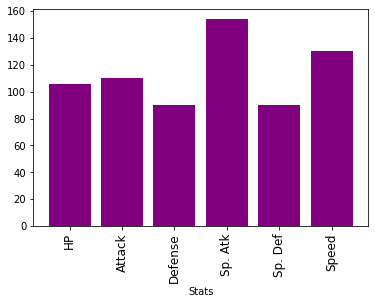

In [76]:
stats = ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']

plt.bar(stats, mewtwo_stats, color='purple')
plt.xticks(stats, rotation='vertical', size=12)
plt.xlabel('Stats')

plt.show()

### How do the top legendary Pokémon compare to the overall average?

Recall that Mewtwo, Ho-oh, and Lugia are the strongest in overall stats:

In [77]:
poke_total_mean.sort_values('Total', ascending=False)[['#','Total']].head(3)

,#,Total
Name,,
Ho-oh,250,680
Mewtwo,150,680
Lugia,249,680


Now let's get the average stats of all the legendary Pokémon but in row form so we can use it to graph:

In [78]:
legendary_stats = legendary_total.mean()[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]
legendary_stats

HP          99.222222
Attack      97.777778
Defense     95.555556
Sp. Atk    110.444444
Sp. Def    109.777778
Speed      100.555556
dtype: float64

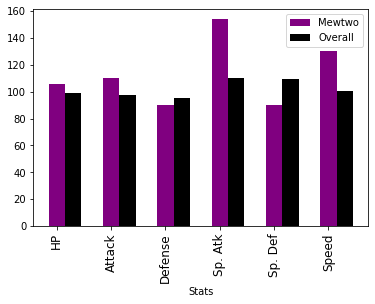

In [79]:
import numpy as np

stats = ('HP','Attack','Defense','Sp. Atk','Sp. Def','Speed')
width = 0.3

plt.bar(np.arange(len(stats)), mewtwo_stats, width, label='Mewtwo', color='purple')
plt.bar(np.arange(len(stats))+width, legendary_stats, width, label='Overall', color='black')
plt.xticks(range(0,len(stats)), stats, rotation='vertical', size=12)

plt.xlabel('Stats')
plt.legend()

plt.show()

Mewtwo's stats are generally much better than the overall average. The only small blemish is the special defence stats that is below that. The defence stats is almost level with the overall average.

In [80]:
hooh_stats = pokedata.loc[(pokedata['Name'] == 'Ho-oh')].mean()[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]
lugia_stats = pokedata.loc[(pokedata['Name'] == 'Lugia')].mean()[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

Now we are going to do the same thing for both Ho-oh and Lugia.

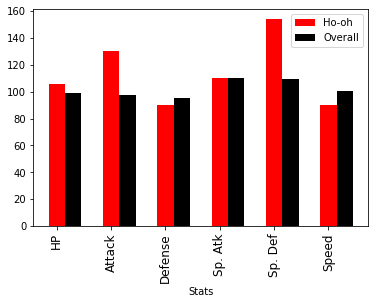

In [81]:
import numpy as np

stats = ('HP','Attack','Defense','Sp. Atk','Sp. Def','Speed')
width = 0.3

plt.bar(np.arange(len(stats)), hooh_stats, width, label='Ho-oh', color='red')
plt.bar(np.arange(len(stats))+width, legendary_stats, width, label='Overall', color='black')
plt.xticks(range(0,len(stats)), stats, rotation='vertical', size=12)

plt.xlabel('Stats')
plt.legend()

plt.show()

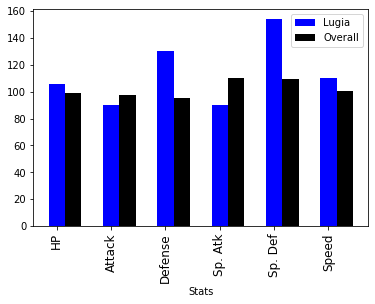

In [82]:
import numpy as np

stats = ('HP','Attack','Defense','Sp. Atk','Sp. Def','Speed')
width = 0.3

plt.bar(np.arange(len(stats)), lugia_stats, width, label='Lugia', color='blue')
plt.bar(np.arange(len(stats))+width, legendary_stats, width, label='Overall', color='black')
plt.xticks(range(0,len(stats)), stats, rotation='vertical', size=12)

plt.xlabel('Stats')
plt.legend()

plt.show()

It looks like Ho-oh beats the average in hit points, attack, and special defence, ties in special attack, and trails in defence and speed. Lugia also beats the average in hit points and special defence but also leads in speed, though it trails in attack and special attack. This just means both legendary Pokémon just play different roles with Ho-oh a bit more offensive and Lugia a bit more defensive.

### Final Question: What is the overall breakdown of all the Pokémon by their primary and secondary typing?

Going back to using pokedata:

In [83]:
pokedata.groupby(['Type 1', 'Type 2']).count()['#']

Type 1    Type 2  
Bug       Fighting     1
          Flying       5
          Grass        2
          Poison       7
          Rock         1
          Steel        2
Dark      Fire         2
          Flying       1
          Ice          1
Dragon    Flying       1
Electric  Flying       1
          Steel        2
Fire      Flying       3
          Rock         1
Ghost     Poison       3
Grass     Flying       3
          Poison       9
          Psychic      2
Ground    Flying       1
          Rock         2
Ice       Flying       2
          Ground       2
          Psychic      2
Normal    Flying      11
          Psychic      1
Poison    Flying       3
          Ground       2
Psychic   Flying       3
          Grass        1
Rock      Dark         1
          Flying       1
          Ground       6
          Water        4
Steel     Flying       1
          Ground       1
Water     Dragon       1
          Electric     2
          Fighting     1
          Flying       2
      

Normal/Flying takes the lead with 11, followed up Grass/Poison with 9 and Bug/Poison with 7. 17 unique primary/secondary typings only have 1 member.

## Credits

Special thanks to:
<br>
https://www.kaggle.com/rounakbanik/pokemon

for the original dataset that got split into the Generation I & II and:
<br>
https://bulbapedia.bulbagarden.net/wiki/Main_Page
<br>
https://www.smogon.com/

for the extra helpful informations along the way.